# EEG practice

This notebook follows the tutorial [EEG Signal Analysis With Python](https://reybahl.medium.com/eeg-signal-analysis-with-python-fdd8b4cbd306/), provided by 
Reyansh Bahl (2023).

In [2]:
import os
import numpy as np
import mne

## Example dataset

In [3]:
sample_data_folder = mne.datasets.sample.data_path()
sample_data_raw_file = os.path.join(sample_data_folder, 'MEG', 'sample', 'sample_audvis_filt-0-40_raw.fif')
raw = mne.io.read_raw_fif(sample_data_raw_file)
raw = raw.pick_types(meg=False, eeg=True, eog=False, exclude='bads')

Opening raw data file /Users/febevansommeren/mne_data/MNE-sample-data/MEG/sample/sample_audvis_filt-0-40_raw.fif...
    Read a total of 4 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
        Average EEG reference (1 x 60)  idle
    Range : 6450 ... 48149 =     42.956 ...   320.665 secs
Ready.
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


## Plot

Using matplotlib as 2D backend.


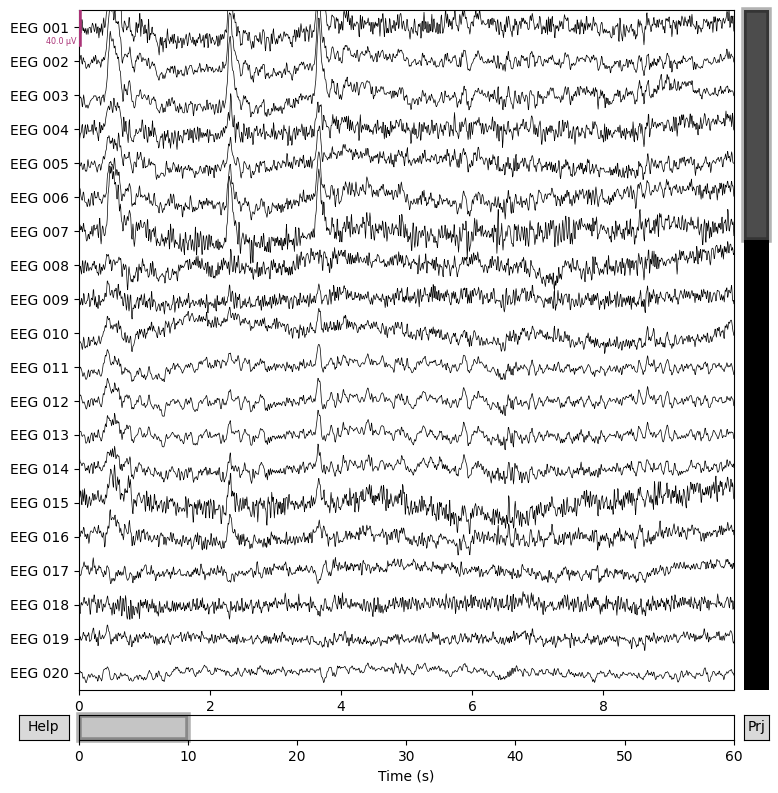

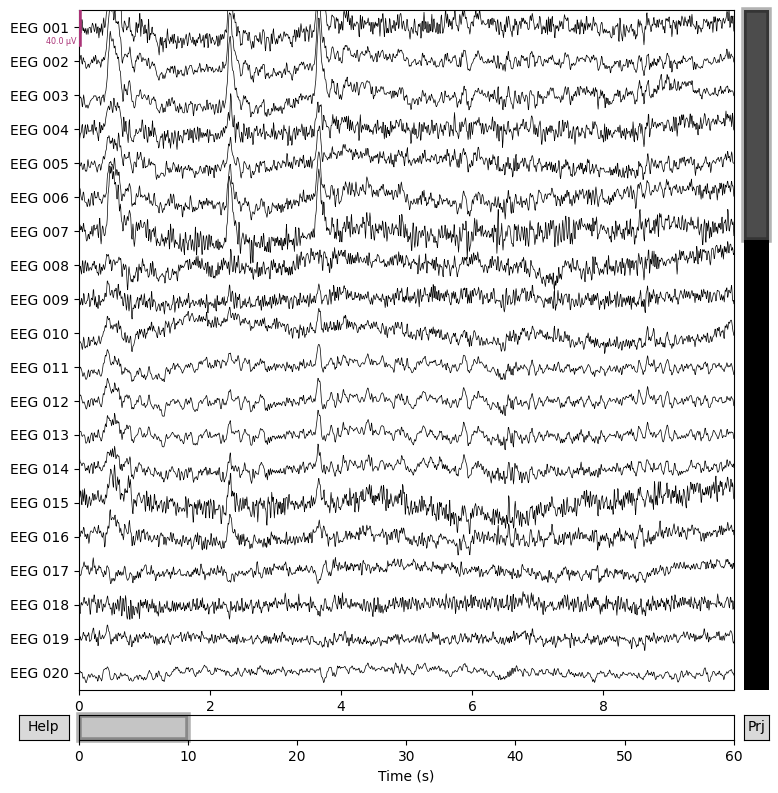

In [4]:
raw.crop(0, 60) # keeps the first minute of data and discards the rest

# plot EEG signals
raw.plot()

## Plot Power spectral density 
In interactive Python sessions, plot functions create interactive plots. These allow for scrolling, scaling, annotations, and more.


NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 13.639 (s)
Plotting power spectral density (dB=True).


/opt/homebrew/lib/python3.11/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


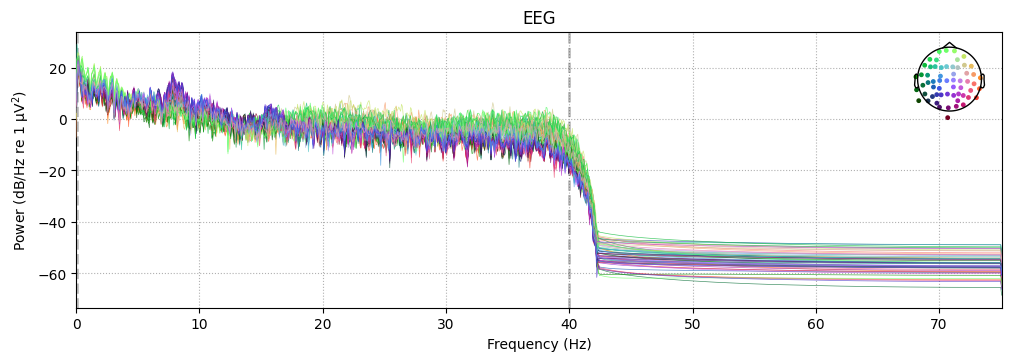

In [5]:
raw.plot_psd()


# Preprocessing

## Resampling
- EEG data often recorded at high-sampling rate (due to high temporal resolution)
- Makes recordings more precise, but consumes more memory
- If highly precise timing is not needed, downsampling the EEG signal can help save a lot of computation time

In [6]:
raw.resample(600) #resamples to a rate of 600 Hz


<Raw | sample_audvis_filt-0-40_raw.fif, 59 x 36003 (60.0 s), ~19.1 MiB, data loaded>

## Filtering
- Preprocessing must be done in order to maximize the signal-to-noise ratio (SNR)
- SNR: measures the ratio of the signal power to the noise power
- Filtering: used for noise reduction/artifact removal 
- Raw objects have a filter method that takes two arguments:
 - lfreq: lower pass-band edge
 - hfreq: upper pass-band edge

### High-pass filtering
- Attenuates frequencies below a certain cutoff frequency
- The rest of the signal remains unchanged

In [7]:
raw.filter(1., None) # filters the signal attenuates the signal below 1 Hz and leaves the rest of the signal unchanged
# High-passed signal

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 1981 samples (3.302 s)



<Raw | sample_audvis_filt-0-40_raw.fif, 59 x 36003 (60.0 s), ~19.1 MiB, data loaded>

### Low-pass filtering
- Attenuates parts of the signal above a certain frequency
- lets frequencies lower than a certain cutoff pass

In [8]:
raw.filter(None, 50.) # attenuates the parts of the signal above 50 Hz and leaves the rest unchanged
# Low-passed signal

Filtering raw data in 1 contiguous segment
Setting up low-pass filter at 50 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 50.00 Hz
- Upper transition bandwidth: 12.50 Hz (-6 dB cutoff frequency: 56.25 Hz)
- Filter length: 159 samples (0.265 s)



<Raw | sample_audvis_filt-0-40_raw.fif, 59 x 36003 (60.0 s), ~19.1 MiB, data loaded>

### Notch Filter (Band Stop filter)
- Combination low-pass and high-pass filters
- It can attenuate signals within a specific range of frequencies
- Stopband: range of frequencies that a band-stop filter attenuates
- often used when removing power-line noise (50/60 Hz)

In [9]:
raw.notch_filter(60)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edge: 60.65 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 60.90 Hz)
- Filter length: 3961 samples (6.602 s)



<Raw | sample_audvis_filt-0-40_raw.fif, 59 x 36003 (60.0 s), ~19.1 MiB, data loaded>

- There may be peaks found at the harmonic frequencies
    - Apply the notch filter to each of these frequencies by using the numpy.arange method
    

In [10]:
# the first 60 is start (inclusive), 241 is stop (exlusive), and 60 is step
raw.notch_filter(np.arange(60, 241, 60))

Filtering raw data in 1 contiguous segment
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 3961 samples (6.602 s)



<Raw | sample_audvis_filt-0-40_raw.fif, 59 x 36003 (60.0 s), ~19.1 MiB, data loaded>

## Epoching
- Epochs: equal-length segments of data extracted from continuous EEG data
- Usually, epochs are extracted around stimulus events or responses, but sometimes sequential or overlapping epochs are used.

- MNE has an *Epochs* object used to represent epoched data
- Epochs objects are used in other steps of EEG analysis, including feature extraction, which is used in machine learning.

In order to create epoched data, MNE-Python requires a Raw object as well as an array of events.

### Events
- provide a mapping between specific times during an EEG/MEG recording and what happened at those times
- Stored in 2D numpy array
- There are two ways to create events: 
  - reading from a file/Raw object
  - creating equal-sized events.

#### Reading Events
(Different sample recording because the one we were originally using does not contain any events)

In [11]:
sample_data_folder = mne.datasets.sample.data_path()
sample_data_raw_file = os.path.join(sample_data_folder, 'MEG', 'sample', 'sample_audvis_raw.fif')
raw = mne.io.read_raw_fif(sample_data_raw_file, verbose=False)

# reads events from a Raw object
events = mne.find_events(raw)

Finding events on: STI 014
320 events found on stim channel STI 014
Event IDs: [ 1  2  3  4  5 32]


#### Creating equal-length events
Sometimes, there may not be any events included in the raw EEG recording. In such cases, an array of equally-spaced events can be generated. The code below creates second-long events for the first 10 seconds of EEG data

In [12]:
events = mne.make_fixed_length_events(raw, start=0, stop=10, duration=1.)


### Creating Epoched data from events
preload=True loads all epochs from disk when creating the Epochs object

In [13]:
epochs = mne.Epochs(raw, events, preload=True).pick_types(eeg=True)

Not setting metadata
10 matching events found
Setting baseline interval to [-0.19979521315838786, 0.0] s
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 3)
3 projection items activated
Loading data for 10 events and 421 original time points ...
1 bad epochs dropped
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


#### Selecting epochs
Now that we have the Epochs object with event labels, we can select epochs using square brackets
For example, we can plot the epochs where the event label was ‘1’ (these event labels have an actual meaning, but they are not shown here for simplicity)

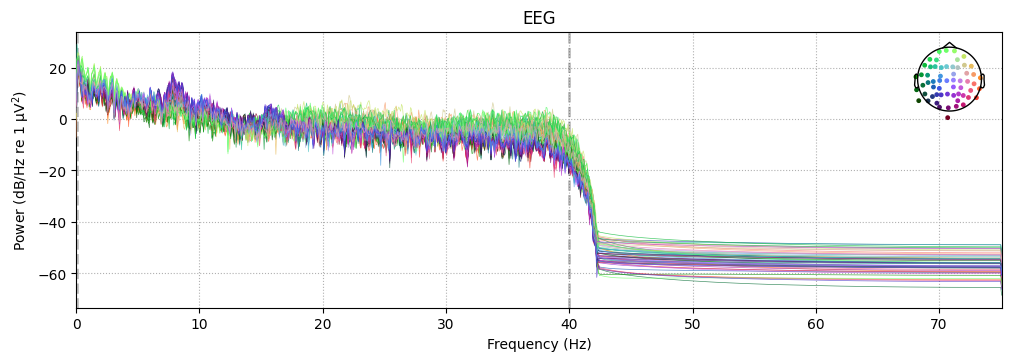

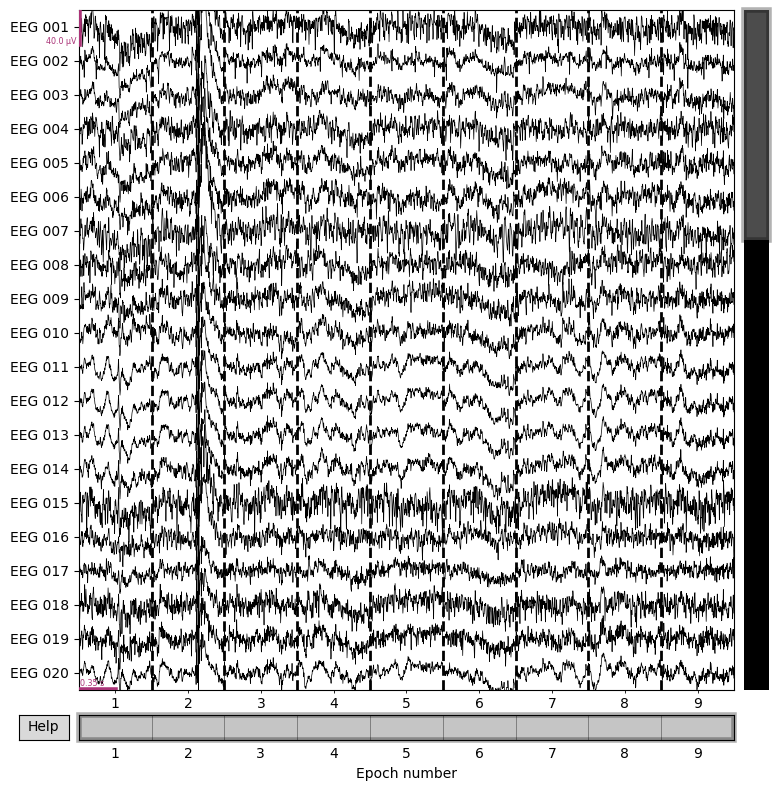

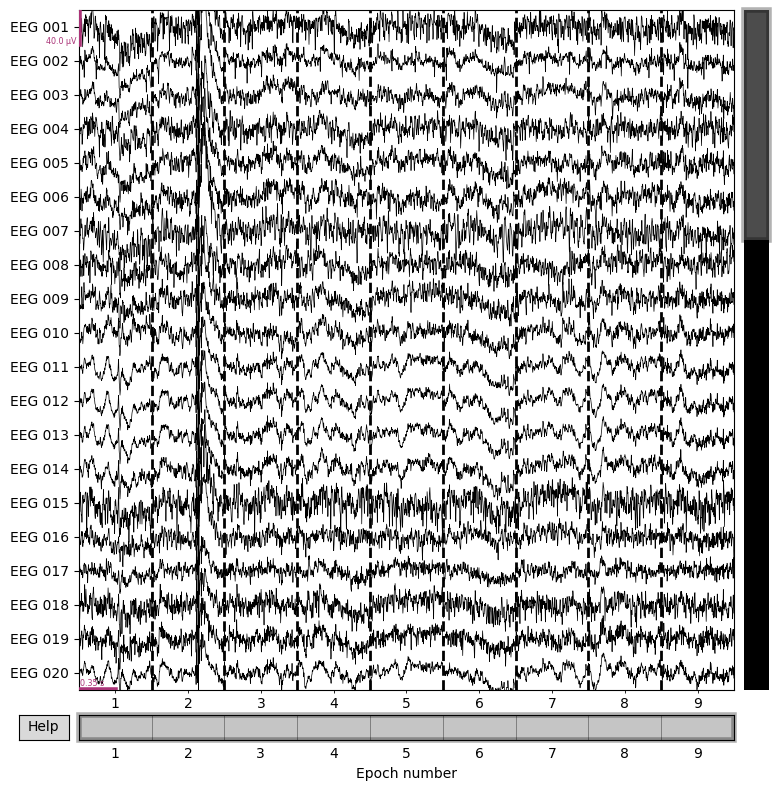

In [14]:
epochs['1'].plot()
